### Pre-reqs


The required dataset for this assignment must be downloaded from the following repository:
https://drive.google.com/drive/folders/1-F8gd-kjQ2a-x2EXJYOaLwHhTt4apNBJ

In [7]:
# import libraries

import gdown
from pathlib import Path
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

In [6]:
google_url = "https://drive.google.com/drive/folders/1-F8gd-kjQ2a-x2EXJYOaLwHhTt4apNBJ"

download_dir = Path("images/")
download_dir.mkdir(parents=True, exist_ok=True)

gdown.download_folder(
    url=google_url,
    output=str(download_dir),
    quiet=False,
    use_cookies=False
)

Retrieving folder contents


Retrieving folder 1EHKH1HdAjUHBnF_fTtGNiccWtuVf88Wx images
Processing file 1PBaVVToKqBhT97BUtDN3USZPPgbm-FYc im1.png
Processing file 13SgFPsosyf2LY7vO-8eu0kV0qFCOIdyt im2.png
Processing file 1l9WbkWSMjJ3wqwRB2uW358r9kr4b5uTl intrinsics.npz
Processing file 1RGfKQTnWSATmLw557wgKJbJRToplOYlD some_corresp.npz


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1PBaVVToKqBhT97BUtDN3USZPPgbm-FYc
To: c:\Users\Luke\OneDrive - Heriot-Watt University\Desktop\Machine Vision\Assignments\asgnmt2\images\images\im1.png
100%|██████████| 7.11M/7.11M [00:01<00:00, 5.42MB/s]
Downloading...
From: https://drive.google.com/uc?id=13SgFPsosyf2LY7vO-8eu0kV0qFCOIdyt
To: c:\Users\Luke\OneDrive - Heriot-Watt University\Desktop\Machine Vision\Assignments\asgnmt2\images\images\im2.png
100%|██████████| 7.07M/7.07M [00:00<00:00, 9.68MB/s]
Downloading...
From: https://drive.google.com/uc?id=1l9WbkWSMjJ3wqwRB2uW358r9kr4b5uTl
To: c:\Users\Luke\OneDrive - Heriot-Watt University\Desktop\Machine Vision\Assignments\asgnmt2\images\intrinsics.npz
100%|██████████| 1.77k/1.77k [00:00<00:00, 4.19MB/s]
Downloading...
From: https://drive.google.com/uc?id=1RGfKQTnWSATmLw557wgKJbJRToplOYlD
To: c:\Users\Luke\OneDrive - Heriot-Watt 

['images\\images\\im1.png',
 'images\\images\\im2.png',
 'images\\intrinsics.npz',
 'images\\some_corresp.npz']

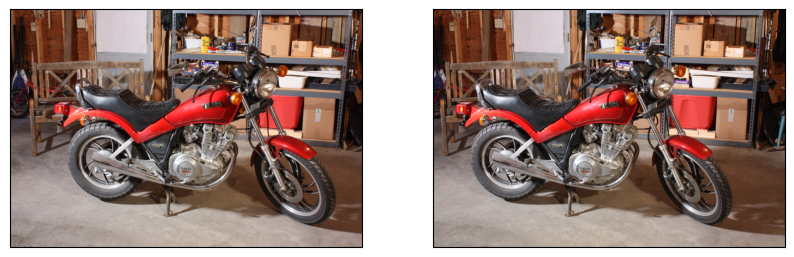

In [ ]:
# display the stereo pair
img1_path = r"images\images\im1.png"
img2_path = r"images\images\im2.png"

img1 = cv.imread(img1_path, 1)
img2 = cv.imread(img2_path, 1)
img1 = cv.cvtColor(img1, cv.COLOR_BGR2RGB)
img2 = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

for a in ax:
    a.set_xticks([])
    a.set_yticks([])

ax[0].imshow(img1)
ax[1].imshow(img2)

plt.show()

In [31]:
# data inputs

data_intrinsics_path = r"images\intrinsics.npz"
data_corresp_path = r"images\some_corresp.npz"

# Section 1 : Sparse Reconstruction

## Part 1.1
Implement the eight-point algorithm to estimate the fundamental matrix (F) that relates the two views
- scale pixel coords by 1/M
- solve using singular valve decomposition (SVD)
- enforce the rank2 constraint by zeroing the smallest singular value before un-normalising F=F^{T}F_{norm}T

required output

- computed 3x3 fundamental matrix (F)
- visulation displing selected points in img 1 and their corresponding epipolar lines in img 2



In [41]:
# load the matched correspondences
data = np.load(data_corresp_path)
pts1 = data["pts1"].astype(np.float64)
pts2 = data["pts2"].astype(np.float64)

if pts1.shape != pts2.shape or pts1.shape[1] != 2:
    raise ValueError("pts1 and pts2 must both have shape (N, 2)")

M = max(img1.shape[0], img1.shape[1], img2.shape[0], img2.shape[1])

T = np.array([
    [1 / M, 0, 0],
    [0, 1 / M, 0],
    [0, 0, 1],
])

pts1_h = np.column_stack([pts1, np.ones(len(pts1))])
pts2_h = np.column_stack([pts2, np.ones(len(pts2))])

pts1_n = (T @ pts1_h.T).T
pts2_n = (T @ pts2_h.T).T

x1, y1 = pts1_n[:, 0], pts1_n[:, 1]
x2, y2 = pts2_n[:, 0], pts2_n[:, 1]

A = np.column_stack([
    x2 * x1, x2 * y1, x2,
    y2 * x1, y2 * y1, y2,
    x1, y1, np.ones_like(x1),
]).astype(np.float64)

print("pts1 shape:", pts1.shape)
print("pts2 shape:", pts2.shape)
print("A shape:", A.shape)

pts1 shape: (3439, 2)
pts2 shape: (3439, 2)
A shape: (3439, 9)


In [42]:
# solve Af = 0 with SVD
_, _, vt = cv.SVDecomp(A)
F_norm = vt[-1].reshape(3, 3)

# enforce rank-2 on the normalized fundamental matrix
w, u, vt = cv.SVDecomp(F_norm)
w[-1, 0] = 0
F_norm = u @ np.diag(w.flatten()) @ vt

# un-normalize back to pixel coordinates
F = T.T @ F_norm @ T

# scale for easier reading
if not np.isclose(F[-1, -1], 0.0):
    F = F / F[-1, -1]

print("Fundamental matrix F:")
print(F)

Fundamental matrix F:
[[ 8.33699099e-10  1.10986303e-06  4.12970867e-04]
 [-9.01071524e-07 -7.33025558e-08  1.23013634e+00]
 [-1.25990883e-03 -1.23001705e+00  1.00000000e+00]]
